# goal


 Simulate the Monty Hall Problem

- Simulate three doors, one car, and two goats.
 - Simulate three players: the switcher, the conservative, and the newcomer. 
 - Record who wins.
 - Repeat it many times.
 - Which player do you want to be?

 - You could plot the winning probabilities as a function of the number of games. That tells you about the variance of your estimator.
 

**Food for thought:** And what if you had $N$ doors to choose from and the presenter opens $p< N$ of them? Study how the probability of winning changes as a function of $p$ and $N$.


# import

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import random
from numpy.random import choice

# 3-doors

In [112]:
def montyhall_3doors(n_cicles, N_doors):  #montyhall, esegue il problema n_cicles volte e ritorna dei vettori con gli indici delle posizioni dei vari player/cars/estrazioni
    cars = np.zeros(n_cicles)
    first = np.zeros(n_cicles)
    drawss = np.zeros(n_cicles)
    second = np.zeros(n_cicles)
    newcomer = np.zeros(n_cicles)
    for i in range (n_cicles):
        cars[i] = random.randint(1, N_doors)
        first[i] = random.randint(1, N_doors)
        drawss[i] = random.randint(1, N_doors)
        while(drawss[i] == first[i] or drawss[i] == cars[i]):
            drawss[i] = random.randint(1, N_doors)
        second[i] = random.randint(1, N_doors)
        while (second[i] == first[i] or second[i] == drawss[i]): 
            second[i] = random.randint(1, N_doors)
        newcomer[i] = random.randint(1, N_doors)
        while(newcomer[i] == drawss[i]):
            newcomer[i] = random.randint(1, N_doors)
    # print("Done")
    return cars, first, second, newcomer

In [113]:
N = 3

car_index = random.randint(1, N)
first_choice = random.randint(1, N)
conservative = random.randint(1, N)
draws = random.randint(1, N)
while(draws == first_choice or draws == car_index):
    draws = random.randint(1, N)
second_choice = random.randint(1, N)
while (second_choice == first_choice or second_choice == draws): 
    second_choice = random.randint(1, N)

# debug
print ("car", car_index, "\n", "first choice", first_choice, "\n", "draws", draws, "\n" )
print ("second choice", second_choice)


car 3 
 first choice 1 
 draws 2 

second choice 3


In [114]:
#lo faccio una volta, vedo se probabilità finale torna
cicles = 1000
cars, conservatives, switchers, newcomers = montyhall_3doors(cicles, 3)
w_events_con = 0  #winning conservatives
w_events_sw = 0  #winning switchers
w_events_nc = 0 #winning newcomer
for i in range (cicles):
    if (cars[i] == conservatives[i]):
        w_events_con += 1

    if (cars[i] == switchers[i]):
        w_events_sw += 1

    if (cars[i] == newcomers[i]):
        w_events_nc += 1

print("probability of conservative winning:", w_events_con/cicles)
print("probability of switcher winning:", w_events_sw/cicles)
print("probability of newcomer winning:", w_events_nc/cicles)

probability of conservative winning: 0.346
probability of switcher winning: 0.654
probability of newcomer winning: 0.522


In [115]:
#it works, now implement in a function to see how it changes with growing cicles

def mh_3doors_wprob(n_cicles,  n_doors):
    con_wprob = np.zeros(n_cicles )
    sw_wprob  = np.zeros(n_cicles )
    nc_wprob  = np.zeros(n_cicles )

    for i in range (n_cicles ):
        cars, conservatives, switchers, newcomers = montyhall_3doors(i+1, n_doors)
        w_events_con = 0
        w_events_sw = 0
        w_event_nc = 0
        for j in range (i):
            if (cars[j] == conservatives[j]):
                w_events_con += 1

            if (cars[j] == switchers[j]):
                w_events_sw += 1

            if (cars[j] == newcomers[j]):
                w_event_nc += 1
            
        con_wprob[i] = w_events_con / (i+1)
        sw_wprob[i]  = w_events_sw  / (i+1)
        nc_wprob[i]  = w_event_nc   / (i+1)
    
    return con_wprob, sw_wprob, nc_wprob

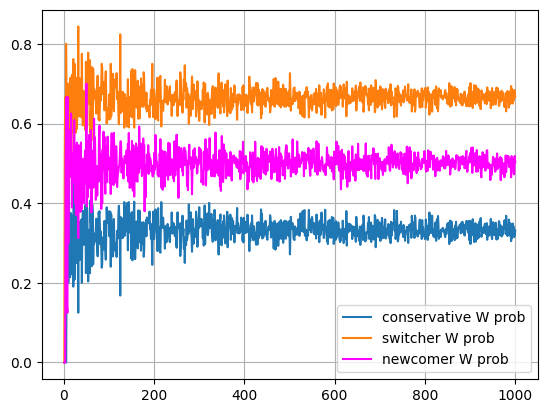

In [116]:
#plotting time

size = 1000
y1, y2, y3 = mh_3doors_wprob(size, 3)
x = np.linspace(1, size, size)
plt.plot(x, y1, label = "conservative W prob")
plt.plot(x, y2, label = "switcher W prob")
plt.plot(x, y3, label = "newcomer W prob", color = "magenta")
plt.legend()
plt.grid()

In [117]:
#now i can compute the varianze after an initial burst

burst = 400

var_con = np.var(y1[burst : size])
m_con = np.mean(y1[burst : size])
var_swi = np.var(y2[burst : size])
m_swi = np.mean(y2[burst : size])
var_nc = np.var(y3[burst : size])
m_nc =  np.mean(y3[burst : size])

print ("mean probability of conservative player winning:", m_con, "+-", var_con)
print ("mean probability of switcher player winning:", m_swi, "+-", var_swi)
print ("mean probability of newcomer player winning:", m_nc, "+-", var_nc)

mean probability of conservative player winning: 0.33268417083465757 +- 0.00033518864758322553
mean probability of switcher player winning: 0.665789927216386 +- 0.0003351990096353446
mean probability of newcomer player winning: 0.5011681377465653 +- 0.00040636953861137134


# N-doors

In [118]:
#devo cambiare metodo per N-doors, P-draws
#I look for the indices 1-N_doors, but they are element of the vector "possible_indices"
N_doors = 3
P_draws = 1
possible_indices = np.linspace(1, N_doors, N_doors)
first = random.randint(1, N_doors) 
car_index = random.randint(1, N_doors) 
possible_indices = possible_indices[(possible_indices != car_index) & (possible_indices != first)]

for i in range (P_draws):
   remove = choice(possible_indices)
   possible_indices = possible_indices[possible_indices != remove]
 
print(first, car_index, possible_indices)

#it seems to work


1 3 []


In [119]:
#I try implementing the previous in a function

def mh_NP(N_doors, P_draws, n_times):
    w_events_con = 0
    w_events_sw = 0
    w_events_nc = 0
    con = np.zeros(n_times)
    swi = np.zeros(n_times)
    new = np.zeros(n_times)
    for i in range (n_times):
        possible_indices = np.linspace(1, N_doors, N_doors)
        first = random.randint(1, N_doors)
        car = random.randint(1, N_doors)
        # print("car & first choice", car, first)
        possible_indices = possible_indices[(possible_indices != car) & (possible_indices != first)]
        # print ("possible indices remaining", possible_indices)
        for j in range (P_draws):
            remove = choice(possible_indices)
            # print("draws:", remove)
            possible_indices = possible_indices[possible_indices != remove]
            # print ("possible indices remaining after draws", possible_indices)
        if (car != first):possible_indices = np.append(possible_indices, car)
        # print("possible choices for switcher:", possible_indices)
        second = choice(possible_indices)
        # print("switcher choice", second)
        possible_indices = np.append(possible_indices, first)
        # print("possible choices for newcomer", possible_indices)
        newcomer = choice(possible_indices)
        if (car == first)    : w_events_con += 1
        if (car == second)   : w_events_sw  += 1
        if (car == newcomer) : w_events_nc  += 1
        con[i] = w_events_con / (i + 1)
        swi[i] = w_events_sw  / (i + 1)
        new[i] = w_events_nc  / (i + 1)
    return con, swi, new
    

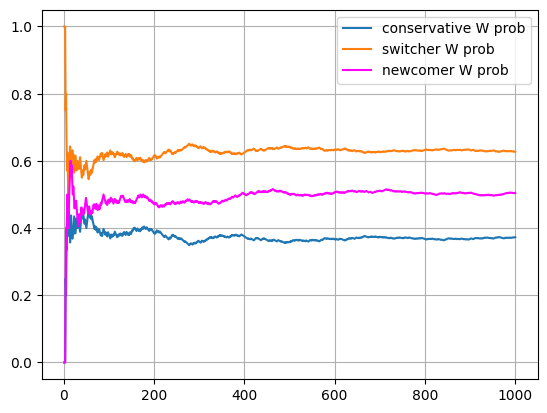

In [120]:
y1, y2, y3 = mh_NP(3, 1, 1000)
x = np.linspace(1, len(y1), len(y1))
plt.plot(x, y1, label = "conservative W prob")
plt.plot(x, y2, label = "switcher W prob")
plt.plot(x, y3, label = "newcomer W prob", color = "magenta")
plt.legend()
plt.grid()
#sembra funzioni così!!

## N = 10

probabilità media di vincità switcher (dopo burst) 0.9181154412174021 *- 3.236193549248149e-06


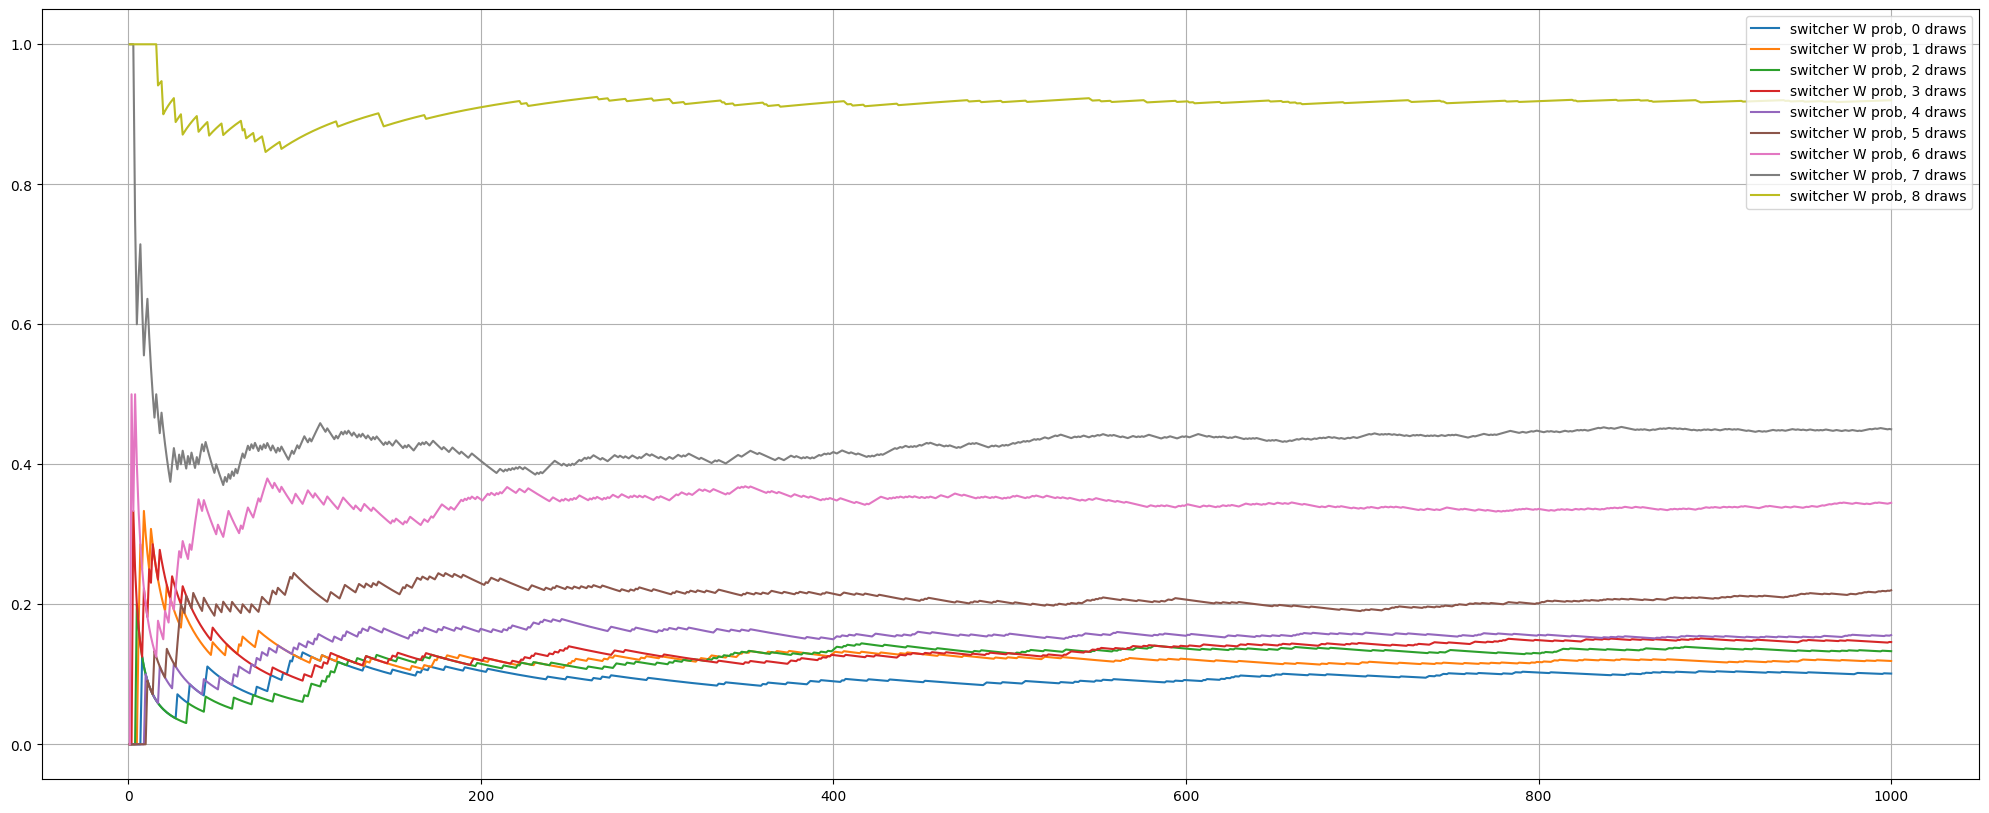

In [ ]:
plt.figure(figsize= (25, 10))
for i in range (9): 
    y1, y2, y3 = mh_NP(10, i, 1000)
    x = np.linspace(1, len(y1), len(y1))
    plt.plot(x, y2, label = f"switcher W prob, {i} draws")
plt.legend()
plt.grid()
print ("probabilità media di vincità switcher (dopo burst), N - 2", np.mean(y2[400:]), "+-", np.var(y2[400:]))

## N = 30

probabilità media di vincità switcher (dopo burst) 0.9585483040258328 *- 2.6944669986706815e-05


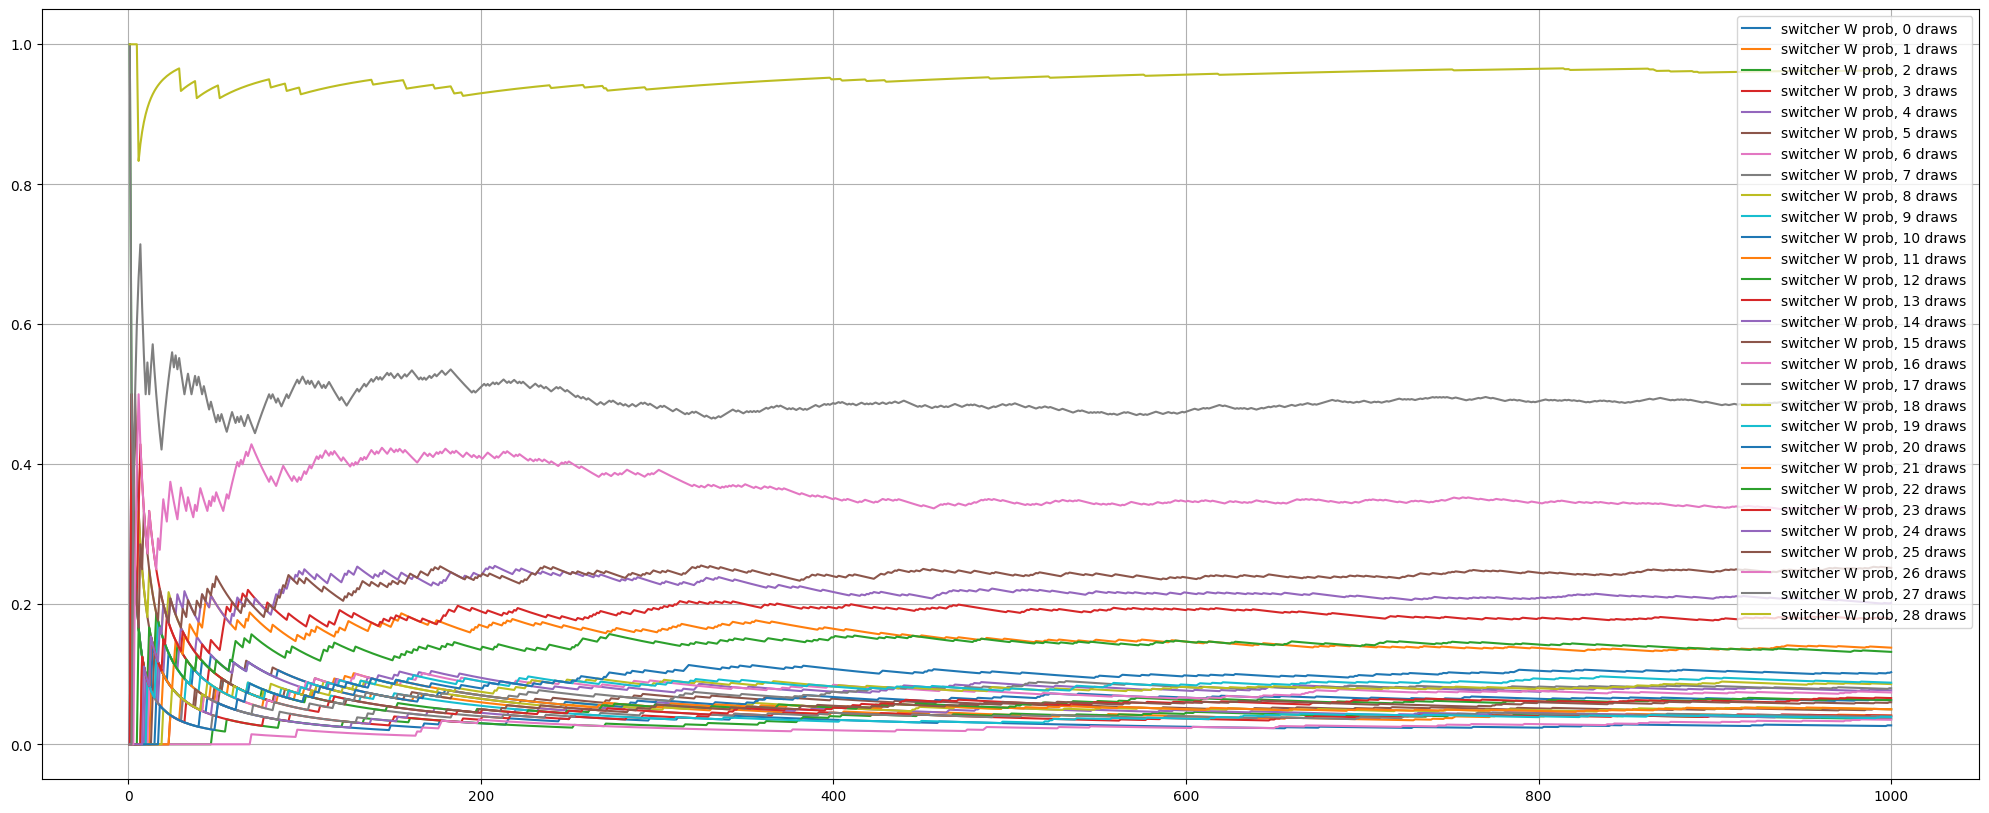

In [ ]:
plt.figure(figsize=(25, 10))
for i in range (29): 
    y1, y2, y3 = mh_NP(30, i, 1000)
    x = np.linspace(1, len(y1), len(y1))
    plt.plot(x, y2, label = f"switcher W prob, {i} draws")
plt.legend()
plt.grid()
print ("probabilità media di vincità switcher (dopo burst), N - 2", np.mean(y2[400:]), "+-", np.var(y2[400:]))

## N = 70

probabilità media di vincità switcher (dopo burst) 0.9844400366201891 *- 1.1606966661623965e-06


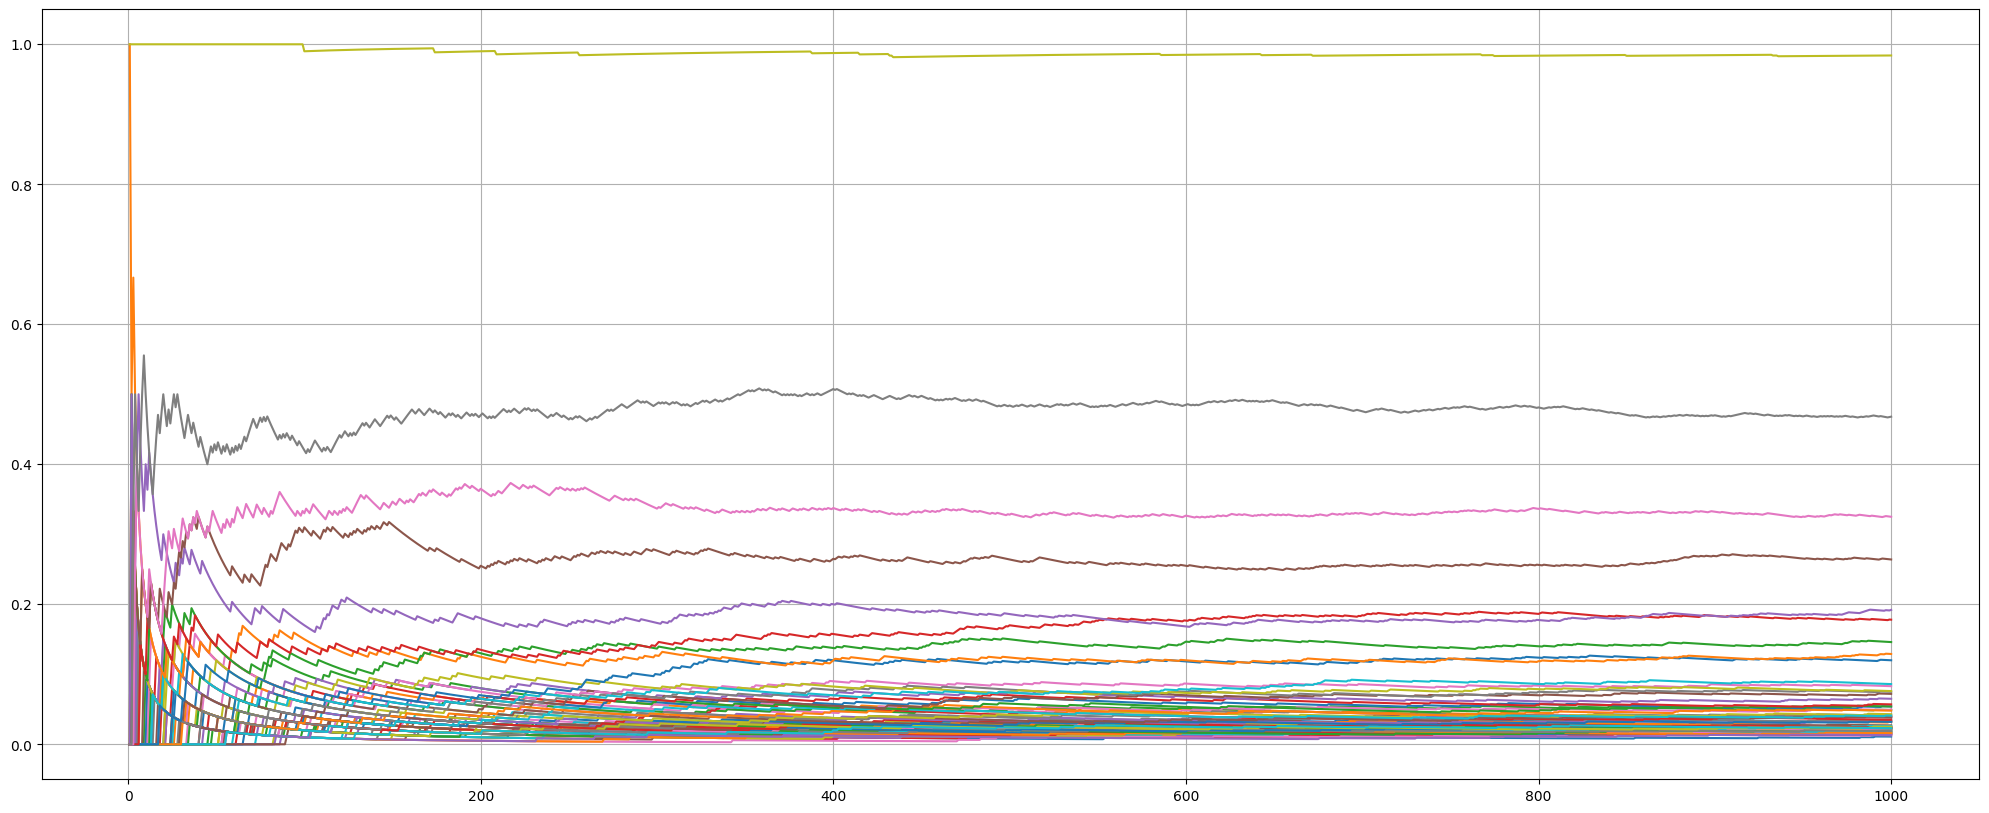

In [ ]:
plt.figure(figsize=(25, 10))
for i in range (69): 
    y1, y2, y3 = mh_NP(70, i, 1000)
    x = np.linspace(1, len(y1), len(y1))
    plt.plot(x, y2, label = f"switcher W prob, {i} draws")
# plt.legend()
plt.grid()
print ("probabilità media di vincità switcher (dopo burst), N - 2", np.mean(y2[400:]), "+-", np.var(y2[400:]))

La scelta di cambiare porta dopo le estrazioni fino ad arrivare a N-2, fa aumentare la probabilità di viincita al crescere di N

## P fixed

probabilità media di vincità switcher (dopo burst) 0.07546716952406957 +- 8.931716505560942e-06


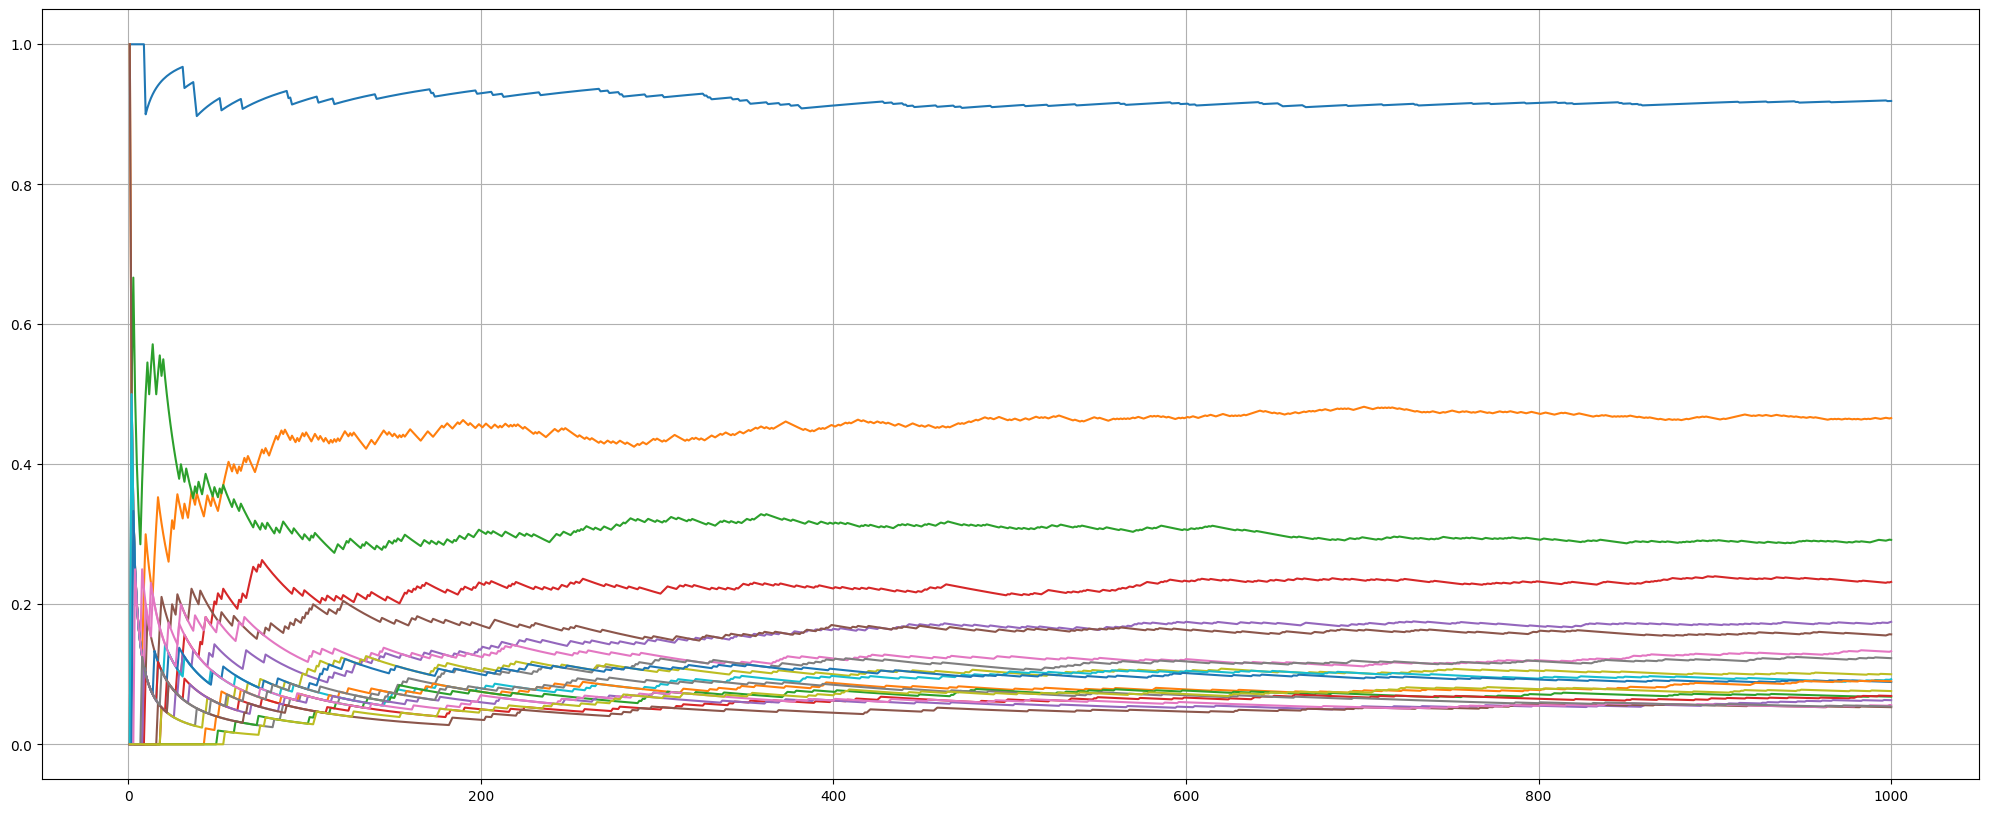

In [154]:
plt.figure(figsize=(25, 10))
for i in range (19): 
    y1, y2, y3 = mh_NP(i+ 12, 10, 1000)
    x = np.linspace(1, len(y1), len(y1))
    plt.plot(x, y2, label = f"switcher W prob, {i + 12} doors, p-fixed at 10 draws")
# plt.legend()
plt.grid()
print ("probabilità media di vincità switcher (dopo burst)", np.mean(y2[400:]), "+-", np.var(y2[400:]))

qui non capisco cosa imparare.